In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_dataset.csv")

df.head()

,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [2]:
project_lengths = (
    df.groupby("project_id")["year"]
      .count()
)

print(project_lengths.describe())
print("\nProjects by number of years:")
print(project_lengths.value_counts().sort_index())

count    500.000000
mean       6.530000
std        2.295133
min        3.000000
25%        4.000000
50%        7.000000
75%        9.000000
max       10.000000
Name: year, dtype: float64

Projects by number of years:
year
3     56
4     73
5     54
6     65
7     65
8     61
9     58
10    68
Name: count, dtype: int64


In [3]:
eligible_projects = project_lengths[
    project_lengths >= 6
].index

print("Total projects:", df["project_id"].nunique())
print("Eligible projects:", len(eligible_projects))

Total projects: 500
Eligible projects: 317


In [5]:
from statsmodels.tsa.arima.model import ARIMA

results = []

for project_id in eligible_projects:

    project = (
        df[df["project_id"] == project_id]
        .sort_values("year")
    )

    cash_flow = project["cash_flow"].values

    train = cash_flow[:5]
    test = cash_flow[5:]

    if len(test) == 0:
        continue

    try:
        model = ARIMA(
            train,
            order=(1, 1, 0)
        )

        fitted_model = model.fit()

        forecast = fitted_model.forecast(
            steps=len(test)
        )

        for actual, predicted in zip(test, forecast):

            results.append({
                "project_id": project_id,
                "actual": actual,
                "predicted": predicted
            })

    except Exception as e:
        print(
            f"ARIMA failed for project {project_id}: {e}"
        )

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [6]:
results_df = pd.DataFrame(results)

results_df.head()

,project_id,actual,predicted
0,P0001,10906457.69,8.882732e+06
1,P0001,7209321.18,8.968822e+06
2,P0001,10192767.52,8.928962e+06
3,P0001,10402911.22,8.947417e+06
4,P0002,9048787.04,9.875728e+06


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    results_df["actual"],
    results_df["predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        results_df["actual"],
        results_df["predicted"]
    )
)

r2 = r2_score(
    results_df["actual"],
    results_df["predicted"]
)

print("ARIMA Results")
print("-------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

ARIMA Results
-------------
MAE : 2782672.6133170268
RMSE: 4200167.146414133
R²  : 0.8181734081129823


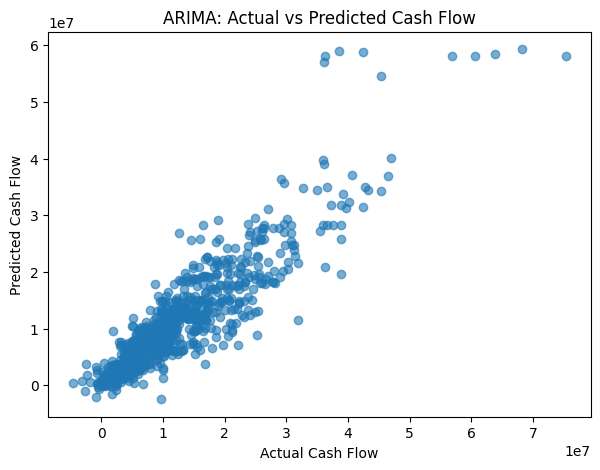

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    results_df["actual"],
    results_df["predicted"],
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("ARIMA: Actual vs Predicted Cash Flow")

plt.show()

In [9]:
arima_result = {
    "model": "ARIMA(1,1,0)",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "eligible_projects": len(eligible_projects)
}

print(arima_result)

{'model': 'ARIMA(1,1,0)', 'MAE': 2782672.6133170268, 'RMSE': np.float64(4200167.146414133), 'R2': 0.8181734081129823, 'eligible_projects': 317}
